In [1]:
import ast
import json
import re
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
movies = pd.read_csv('../datasets/movies_main.csv')
display(movies)

,id,title,release_date,budget,revenue
0,862,Toy Story,10/30/1995,30000000,373554033.0
1,8844,Jumanji,12/15/1995,65000000,262797249.0
2,15602,Grumpier Old Men,1995-12-22,0,0.0
3,31357,Waiting to Exhale,12/22/1995,0,81452156.0
4,11862,Father of the Bride Part II,1995-02-10,0,76578911.0
...,...,...,...,...,...
45481,21721,Eddie and the Cruisers,1983-09-23,0,4786789.0
45482,421365,The other me,2017-01-19,0,0.0
45483,65096,EMR,01/01/2004,150000,0.0
45484,13061,Your Friend the Rat,2007-11-06,0,0.0


In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45486 entries, 0 to 45485
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            45486 non-null  object 
 1   title         45480 non-null  object 
 2   release_date  45396 non-null  object 
 3   budget        41051 non-null  object 
 4   revenue       45480 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.7+ MB


In [4]:
movies.describe()

,revenue
count,4.548000e+04
mean,1.120587e+07
std,6.431874e+07
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.787965e+09


In [5]:
movies.isnull().sum()

id                 0
title              6
release_date      90
budget          4435
revenue            6
dtype: int64

In [6]:
movies_extended = pd.read_csv('../datasets/movie_extended.csv')
display(movies_extended.head())

,id,genres,production_companies,production_countries,spoken_languages
0,862,"Animation,Comedy,Family",Pixar Animation Studios,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]"
1,8844,"Adventure,Fantasy,Family","TriStar Pictures,Teitler Film,Interscope Commu...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso..."
2,15602,"Romance,Comedy","Warner Bros.,Lancaster Gate","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]"
3,31357,"Comedy,Drama,Romance",Twentieth Century Fox Film Corporation,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]"
4,11862,Comedy,"Sandollar Productions,Touchstone Pictures","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]"


In [7]:
def split_csv(val):
    """Split a comma-separated string into a stripped list; return [] for non-strings."""
    return [s.strip() for s in val.split(',')] if isinstance(val, str) else []

def extract_names(val):
    """Parse a stringified list-of-dicts and return the 'name' values."""
    try:
        lst = ast.literal_eval(val) if isinstance(val, str) else []
        return [d.get('name', '') for d in lst if isinstance(d, dict)] if isinstance(lst, list) else []
    except (ValueError, SyntaxError):
        return []

movies_extended['genres_list']               = movies_extended['genres'].map(split_csv)
movies_extended['production_companies_list'] = movies_extended['production_companies'].map(split_csv)
movies_extended['country_names']             = movies_extended['production_countries'].map(extract_names)
movies_extended['language_names']            = movies_extended['spoken_languages'].map(extract_names)

movies_extended[['id', 'genres_list', 'production_companies_list', 'country_names', 'language_names']].head()


,id,genres_list,production_companies_list,country_names,language_names
0,862,"[Animation, Comedy, Family]",[Pixar Animation Studios],[United States of America],[English]
1,8844,"[Adventure, Fantasy, Family]","[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],"[English, Français]"
2,15602,"[Romance, Comedy]","[Warner Bros., Lancaster Gate]",[United States of America],[English]
3,31357,"[Comedy, Drama, Romance]",[Twentieth Century Fox Film Corporation],[United States of America],[English]
4,11862,[Comedy],"[Sandollar Productions, Touchstone Pictures]",[United States of America],[English]


In [8]:
# Explode each list column and compute value counts
genre_counts    = movies_extended.explode('genres_list')['genres_list'].str.strip().value_counts()
country_counts  = movies_extended.explode('country_names')['country_names'].value_counts()
language_counts = movies_extended.explode('language_names')['language_names'].value_counts()

for label, counts in [('genres', genre_counts), ('countries', country_counts), ('languages', language_counts)]:
    print(f"Top 10 {label}:\n{counts.head(10)}\n")


Top 10 genres:
genres_list
Drama              20265
Comedy             13182
Thriller            7624
Romance             6735
Action              6596
Horror              4673
Crime               4307
Documentary         3932
Adventure           3496
Science Fiction     3049
Name: count, dtype: int64

Top 10 countries:
country_names
United States of America    21153
United Kingdom               4094
France                       3938
Germany                      2253
Italy                        2168
Canada                       1764
Japan                        1648
Spain                         964
Russia                        912
India                         828
Name: count, dtype: int64

Top 10 languages:
language_names
English      28745
Français      4196
Deutsch       2625
Español       2413
Italiano      2367
日本語           1758
Pусский       1563
普通话            790
हिन्दी         707
Português      591
Name: count, dtype: int64



In [9]:
ratings = (
    pd.read_json('../datasets/ratings.json')
    .assign(
        avg_rating    = lambda df: df['ratings_summary'].map(lambda x: x.get('avg_rating')),
        total_ratings = lambda df: df['ratings_summary'].map(lambda x: x.get('total_ratings')),
        last_rated    = lambda df: pd.to_datetime(df['last_rated'], unit='s'),
    )
    .drop(columns='ratings_summary')
)

display(ratings.head())
print(f"Shape: {ratings.shape}  |  dtypes: {dict(ratings.dtypes)}")


,movie_id,last_rated,avg_rating,total_ratings
0,1,2016-10-06 19:55:11,3.872470,247
1,2,2016-08-01 17:42:33,3.401869,107
2,3,2016-08-16 22:07:21,3.161017,59
3,4,2004-07-27 06:14:12,2.384615,13
4,5,2016-08-16 22:15:47,3.267857,56


Shape: (9066, 4)  |  dtypes: {'movie_id': dtype('int64'), 'last_rated': dtype('<M8[ns]'), 'avg_rating': dtype('float64'), 'total_ratings': dtype('int64')}


## Visualizations

/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4135/3080317294.py:14: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layou

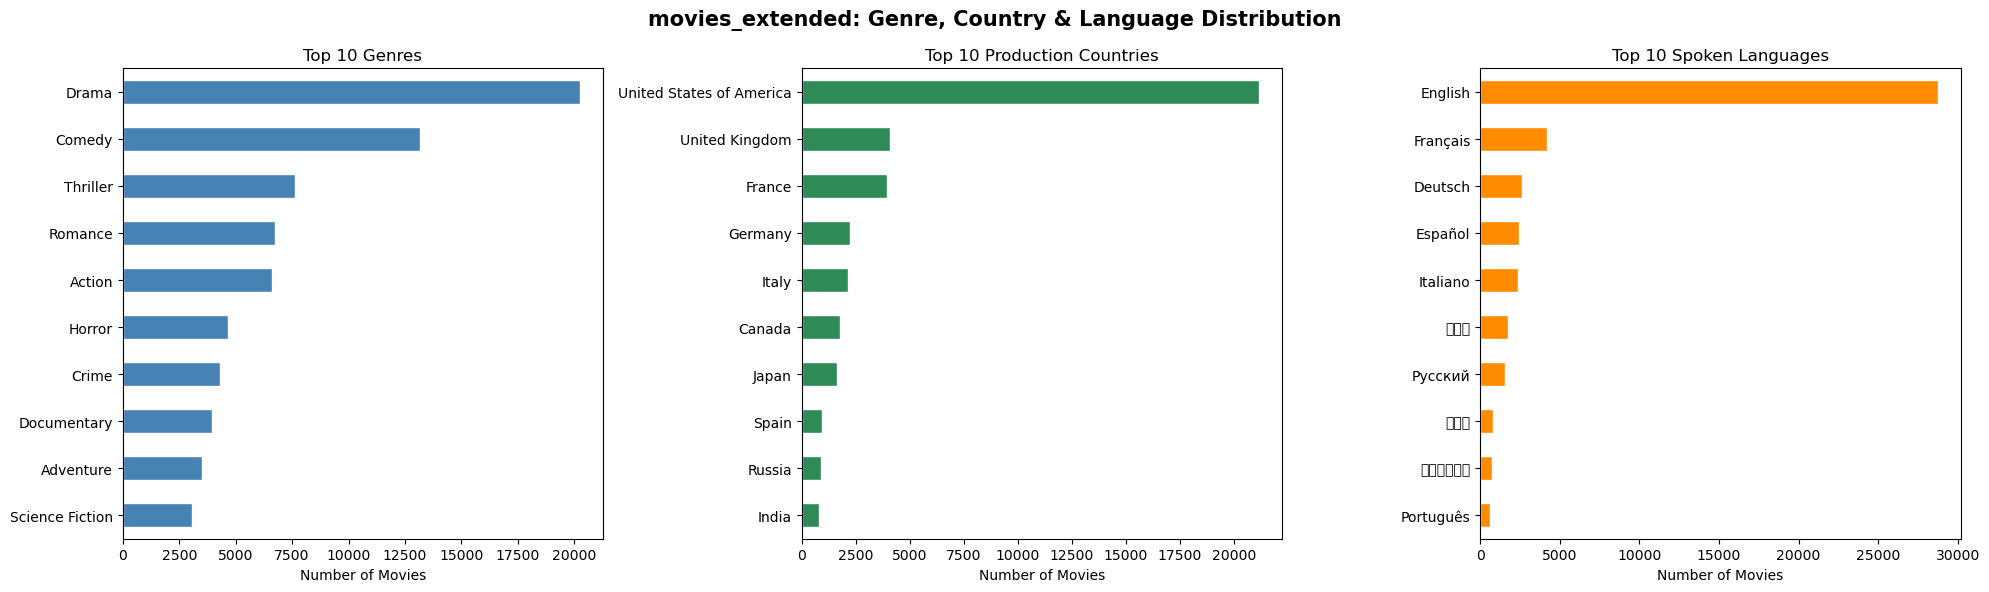

In [10]:
bar_charts = [
    (genre_counts,    'Top 10 Genres',               'steelblue'),
    (country_counts,  'Top 10 Production Countries',  'seagreen'),
    (language_counts, 'Top 10 Spoken Languages',      'darkorange'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('movies_extended: Genre, Country & Language Distribution', fontsize=15, fontweight='bold')

for ax, (data, title, color) in zip(axes, bar_charts):
    data.head(10).sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set(title=title, xlabel='Number of Movies', ylabel='')

plt.tight_layout()
plt.show()


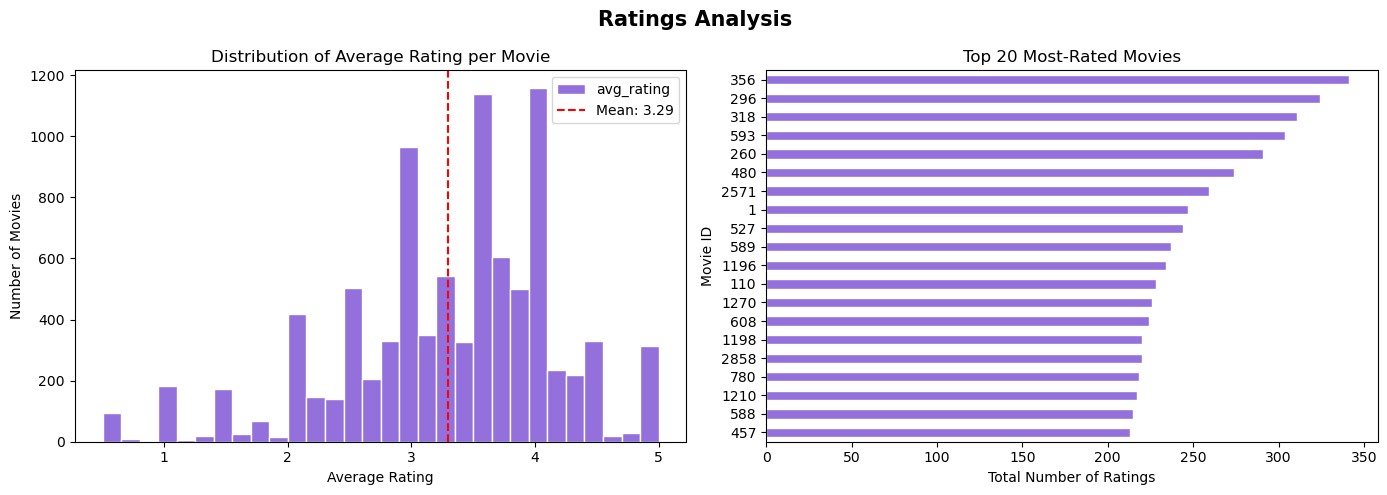

Total movies with ratings: 9,066
Mean avg rating:               3.29
Median total ratings per movie: 3


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ratings Analysis', fontsize=15, fontweight='bold')

# Histogram of average ratings per movie
ratings['avg_rating'].dropna().plot(
    kind='hist', bins=30, ax=axes[0],
    color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Distribution of Average Rating per Movie')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(ratings['avg_rating'].mean(), color='red', linestyle='--', label=f"Mean: {ratings['avg_rating'].mean():.2f}")
axes[0].legend()

# Top 20 most-rated movies by total rating count
top_popular = ratings.sort_values('total_ratings', ascending=False).head(20)
top_popular.set_index('movie_id')['total_ratings'].sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white'
)
axes[1].set_title('Top 20 Most-Rated Movies')
axes[1].set_xlabel('Total Number of Ratings')
axes[1].set_ylabel('Movie ID')

plt.tight_layout()
plt.show()

print(f"Total movies with ratings: {len(ratings):,}")
print(f"Mean avg rating:               {ratings['avg_rating'].mean():.2f}")
print(f"Median total ratings per movie: {ratings['total_ratings'].median():.0f}")


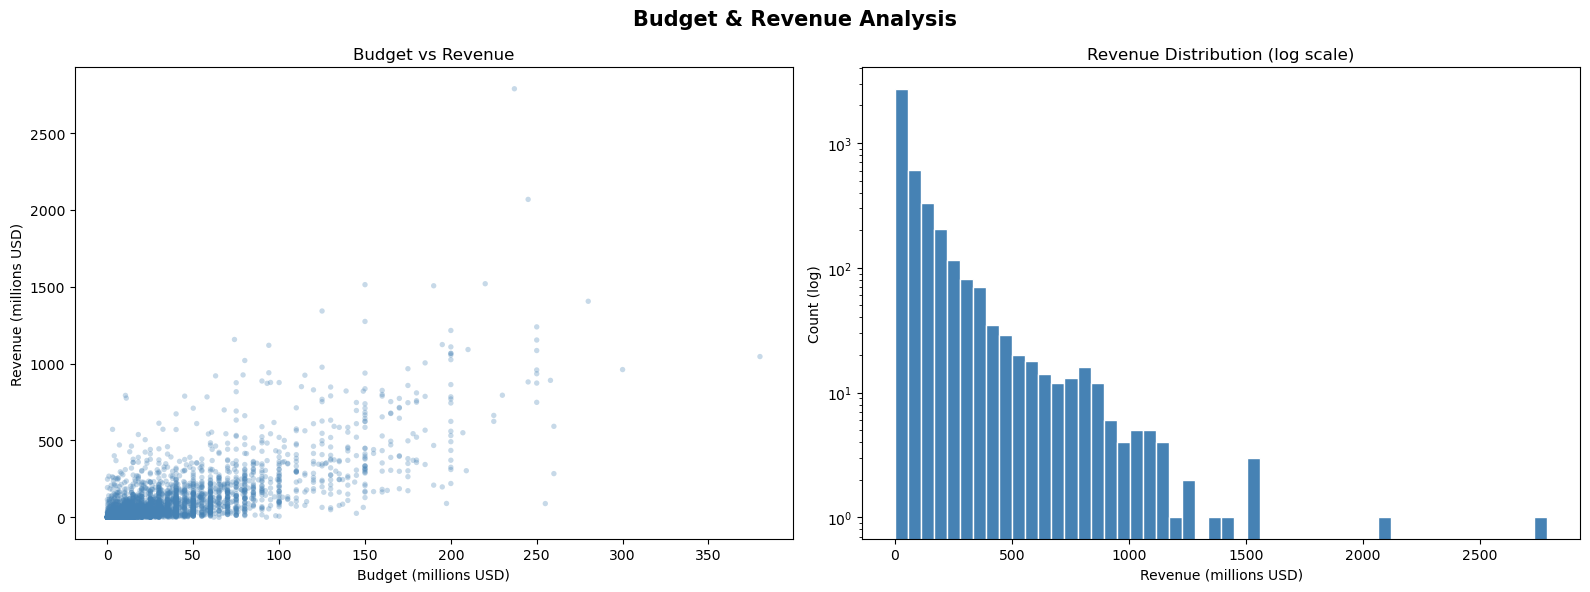

Movies with budget & revenue: 4,339
Median budget:  $17.0M
Median revenue: $29.7M


In [12]:
movies_plot = movies.assign(
    budget  = pd.to_numeric(movies['budget'],  errors='coerce'),
    revenue = pd.to_numeric(movies['revenue'], errors='coerce'),
).query('budget > 0 and revenue > 0')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Budget & Revenue Analysis', fontsize=15, fontweight='bold')

axes[0].scatter(movies_plot['budget'] / 1e6, movies_plot['revenue'] / 1e6,
                alpha=0.3, color='steelblue', edgecolors='none', s=15)
axes[0].set(title='Budget vs Revenue', xlabel='Budget (millions USD)', ylabel='Revenue (millions USD)')

(movies_plot['revenue'] / 1e6).plot(kind='hist', bins=50, ax=axes[1],
                                     color='steelblue', edgecolor='white', log=True)
axes[1].set(title='Revenue Distribution (log scale)', xlabel='Revenue (millions USD)', ylabel='Count (log)')

plt.tight_layout()
plt.show()

print(f"Movies with budget & revenue: {len(movies_plot):,}")
print(f"Median budget:  ${movies_plot['budget'].median()/1e6:.1f}M")
print(f"Median revenue: ${movies_plot['revenue'].median()/1e6:.1f}M")


---
## Phase 1: Structural Profiling — The "Skeleton"

In [13]:
# ── 1. Key Uniqueness ────────────────────────────────────────────────────────
print("=== Key Uniqueness ===")
for df, id_col, name in [(movies, 'id', 'movies'), (movies_extended, 'id', 'movies_extended'), (ratings, 'movie_id', 'ratings')]:
    print(f"{name:18s} — {id_col} unique: {df[id_col].is_unique}  ({df[id_col].nunique():,} unique / {len(df):,} rows)")

# ── 2. Cross-File Integrity ───────────────────────────────────────────────────
print("\n=== Cross-File ID Integrity ===")
main_ids     = set(movies['id'].astype(str))
extended_ids = set(movies_extended['id'].astype(str))
ratings_ids  = set(ratings['movie_id'].astype(str))

checks = [
    ('movie_extended IDs not in movies_main', extended_ids - main_ids),
    ('ratings IDs not in movies_main',        ratings_ids  - main_ids),
    ('movies_main IDs not in movie_extended', main_ids     - extended_ids),
]
for label, orphans in checks:
    print(f"{label}: {len(orphans):,}" + (f"  sample: {list(orphans)[:5]}" if orphans else ""))

# ── 3. JSON Schema Inspection ────────────────────────────────────────────────
print("\n=== ratings.json Schema (first 3 raw records) ===")
with open('../datasets/ratings.json') as f:
    raw = json.load(f)
print(f"Top-level type: {type(raw).__name__},  length: {len(raw)}")
for record in raw[:3]:
    print(record)


=== Key Uniqueness ===
movies             — id unique: False  (45,436 unique / 45,486 rows)
movies_extended    — id unique: False  (45,436 unique / 45,466 rows)
ratings            — movie_id unique: True  (9,066 unique / 9,066 rows)

=== Cross-File ID Integrity ===
movie_extended IDs not in movies_main: 0
ratings IDs not in movies_main: 6,236  sample: ['4040', '4401', '94070', '111360', '4743']
movies_main IDs not in movie_extended: 0

=== ratings.json Schema (first 3 raw records) ===
Top-level type: list,  length: 9066
{'movie_id': 1, 'ratings_summary': {'avg_rating': 3.8724696356275303, 'total_ratings': 247, 'std_dev': 0.9589814920649079}, 'last_rated': 1475783711}
{'movie_id': 2, 'ratings_summary': {'avg_rating': 3.4018691588785046, 'total_ratings': 107, 'std_dev': 0.8807138301648417}, 'last_rated': 1470073353}
{'movie_id': 3, 'ratings_summary': {'avg_rating': 3.1610169491525424, 'total_ratings': 59, 'std_dev': 1.1501149791325278}, 'last_rated': 1471385241}


---
## Phase 2: Data Quality & Anomalies — The "Rubric" Problems

In [14]:
# ── 4. Duplicate Analysis ─────────────────────────────────────────────────────
print("=== Duplicate Analysis (movies_main) ===")
exact_dups = movies.duplicated().sum()
id_dups    = movies.duplicated(subset=['id']).sum()
print(f"Exact row duplicates:     {exact_dups:,}")
print(f"Duplicate movie IDs only: {id_dups:,}")
if id_dups > 0:
    print(f"  → Conflicting records (same ID, different data): {id_dups - exact_dups}")
    display(movies[movies.duplicated(subset=['id'], keep=False)].head(6))

# ── 5. Date Format Audit ──────────────────────────────────────────────────────
print("\n=== Date Format Audit (release_date) ===")
dates  = movies['release_date'].dropna()
parsed = pd.to_datetime(dates, errors='coerce')
print(f"Total: {len(dates):,}  |  Parsed OK: {parsed.notna().sum():,}  |  Failed: {parsed.isna().sum():,}")

patterns = {'YYYY-MM-DD': r'^\d{4}-\d{2}-\d{2}$', 'MM/DD/YYYY': r'^\d{2}/\d{2}/\d{4}$', 'DD-MM-YYYY': r'^\d{2}-\d{2}-\d{4}$'}
for fmt, pat in patterns.items():
    print(f"  {fmt}: {dates.str.match(pat).sum():,} rows")

# ── 6 & 7. Budget / Revenue Zero & Null Profile ───────────────────────────────
print("\n=== Budget & Revenue Profile ===")
movies['budget_num'] = pd.to_numeric(movies['budget'], errors='coerce')
for col in ['budget_num', 'revenue']:
    null_pct  = movies[col].isnull().mean() * 100
    zero_pct  = (movies[col] == 0).mean() * 100
    print(f"{col:12s}  null: {null_pct:.1f}%  zero: {zero_pct:.1f}%  valid: {100-null_pct-zero_pct:.1f}%")
print(f"Both zero: {((movies['budget_num'] == 0) & (movies['revenue'] == 0)).sum():,} rows")


=== Duplicate Analysis (movies_main) ===
Exact row duplicates:     6
Duplicate movie IDs only: 50
  → Conflicting records (same ID, different data): 44


,id,title,release_date,budget,revenue
180,48787,Mute Witness,1995-09-28,2,1.0
676,105045,The Promise,16-02-1995,0,0.0
838,132641,Wife,29-04-1953,0,0.0
949,22649,A Farewell to Arms,12/08/1932,4,25.0
1465,105045,The Promise,02/16/1995,0,0.0
2564,84198,A Place at the Table,2012-03-22,0,0.0



=== Date Format Audit (release_date) ===
Total: 45,396  |  Parsed OK: 15,067  |  Failed: 30,329
  YYYY-MM-DD: 15,194 rows
  MM/DD/YYYY: 15,067 rows
  DD-MM-YYYY: 15,135 rows

=== Budget & Revenue Profile ===
budget_num    null: 9.8%  zero: 74.5%  valid: 15.7%
revenue       null: 0.0%  zero: 83.7%  valid: 16.3%
Both zero: 31,534 rows


---
## Phase 3: Cardinality & Multi-Value Profiling — For the ERD

In [15]:
# ── 8. Multi-Value Delimiter Check ────────────────────────────────────────────
print("=== Multi-Value Delimiter Check (movie_extended) ===")
sample_genres    = movies_extended['genres'].dropna().head(5).tolist()
sample_companies = movies_extended['production_companies'].dropna().head(5).tolist()
print("Sample genres values:")
for v in sample_genres:
    print(f"  {repr(v)}")
print("Sample production_companies values:")
for v in sample_companies:
    print(f"  {repr(v)}")

# Check for leading/trailing spaces in genre tokens
has_spaces_genres = movies_extended['genres'].dropna().str.contains(r',\s|\s,').any()
has_spaces_co     = movies_extended['production_companies'].dropna().str.contains(r',\s|\s,').any()
print(f"\nLeading/trailing spaces around commas — genres: {has_spaces_genres}, companies: {has_spaces_co}")

# ── 9. Max Cardinality ────────────────────────────────────────────────────────
print("\n=== Genre Cardinality per Movie ===")
genre_lengths = movies_extended['genres'].dropna().str.split(',').str.len()
print(f"Max genres per movie:    {genre_lengths.max()}")
print(f"Mean genres per movie:   {genre_lengths.mean():.2f}")
print(f"Median genres per movie: {genre_lengths.median()}")
print(genre_lengths.value_counts().sort_index().rename('movie_count').to_frame())

# ── 10. Unique Dimension Counts ────────────────────────────────────────────────
print("\n=== Unique Dimension Counts ===")
unique_genres    = movies_extended['genres_list'].explode().str.strip().dropna()
unique_companies = movies_extended['production_companies_list'].explode().str.strip().dropna()
unique_countries = movies_extended['country_names'].explode().str.strip().dropna()

print(f"Unique genres:               {unique_genres.nunique():,}  → dim_genre rows")
print(f"Unique production companies: {unique_companies.nunique():,}  → dim_company rows")
print(f"Unique production countries: {unique_countries.nunique():,}  → dim_country rows")
print(f"\nTop genres:    {unique_genres.value_counts().head(5).index.tolist()}")
print(f"Top companies: {unique_companies.value_counts().head(5).index.tolist()}")
print(f"Top countries: {unique_countries.value_counts().head(5).index.tolist()}")


=== Multi-Value Delimiter Check (movie_extended) ===
Sample genres values:
  'Animation,Comedy,Family'
  'Adventure,Fantasy,Family'
  'Romance,Comedy'
  'Comedy,Drama,Romance'
  'Comedy'
Sample production_companies values:
  'Pixar Animation Studios'
  'TriStar Pictures,Teitler Film,Interscope Communications'
  'Warner Bros.,Lancaster Gate'
  'Twentieth Century Fox Film Corporation'
  'Sandollar Productions,Touchstone Pictures'

Leading/trailing spaces around commas — genres: False, companies: True

=== Genre Cardinality per Movie ===
Max genres per movie:    8
Mean genres per movie:   2.12
Median genres per movie: 2.0
        movie_count
genres             
1             14559
2             14480
3              9586
4              3380
5               835
6               157
7                24
8                 3

=== Unique Dimension Counts ===
Unique genres:               32  → dim_genre rows
Unique production companies: 23,006  → dim_company rows
Unique production countries: 158  

---
## Phase 4: Financial & Statistical Profiling — The "Business" Logic

=== Value Ranges ===
budget_num    min: $              1   max: $    380,000,000   median: $     17,000,000
revenue       min: $              1   max: $  2,787,965,087   median: $     29,712,172

Budget < $10k (likely errors): 47


,title,budget_num,revenue
180,Mute Witness,2.0,1.0
185,The Prophecy,8.0,16.0
274,Miami Rhapsody,6.0,5.0
922,East of Eden,1.0,5.0
949,A Farewell to Arms,4.0,25.0



=== Budget Tiering ===
Low  < $8,500,000  |  Mid $8,500,000–$30,000,000  |  High > $30,000,000
budget_tier
Low     1447
Mid     1511
High    1381
Name: count, dtype: int64


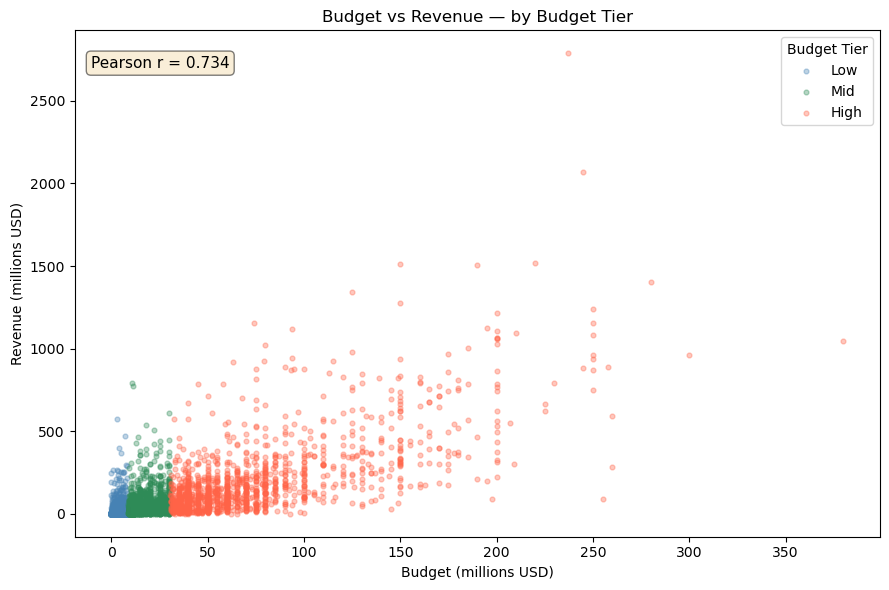

Pearson correlation (budget vs revenue): 0.734


In [16]:
# Reuse budget_num from Phase 2; filter to valid rows only
fin_valid = movies.assign(revenue=pd.to_numeric(movies['revenue'], errors='coerce')).query('budget_num > 0 and revenue > 0')

# ── 11. Value Ranges ───────────────────────────────────────────────────────────
print("=== Value Ranges ===")
for col in ['budget_num', 'revenue']:
    s = fin_valid[col]
    print(f"{col:12s}  min: ${s.min():>15,.0f}   max: ${s.max():>15,.0f}   median: ${s.median():>15,.0f}")

errors = fin_valid[fin_valid['budget_num'] < 10_000]
print(f"\nBudget < $10k (likely errors): {len(errors)}")
display(errors[['title', 'budget_num', 'revenue']].head(5))

# ── 12. Budget Tiering ────────────────────────────────────────────────────────
print("\n=== Budget Tiering ===")
p33, p66 = fin_valid['budget_num'].quantile([0.33, 0.66])
print(f"Low  < ${p33:,.0f}  |  Mid ${p33:,.0f}–${p66:,.0f}  |  High > ${p66:,.0f}")

fin_valid = fin_valid.assign(
    budget_tier = pd.cut(fin_valid['budget_num'], bins=[0, p33, p66, float('inf')], labels=['Low', 'Mid', 'High'])
)
print(fin_valid['budget_tier'].value_counts().sort_index())

# ── 13. Budget vs Revenue Scatter ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
tier_colors = {'Low': 'steelblue', 'Mid': 'seagreen', 'High': 'tomato'}
for tier, grp in fin_valid.groupby('budget_tier', observed=True):
    ax.scatter(grp['budget_num'] / 1e6, grp['revenue'] / 1e6,
               alpha=0.35, s=12, label=tier, color=tier_colors[tier])

corr = fin_valid[['budget_num', 'revenue']].corr().iloc[0, 1]
ax.set(title='Budget vs Revenue — by Budget Tier', xlabel='Budget (millions USD)', ylabel='Revenue (millions USD)')
ax.legend(title='Budget Tier')
ax.text(0.02, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
print(f"Pearson correlation (budget vs revenue): {corr:.3f}")
